# Drift Simulation

Copyright 2026, Battelle Energy Alliance, LLC, ALL RIGHTS RESERVED

Assuming we only train on 2002 to 2017, how many timesteps will it take for each of the models to drift from an acceptable range?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

import FeatureEngineering

plt.rcParams['figure.figsize'] = (7, 5)
plt.rcParams['figure.dpi'] = 125

In [2]:
# Does not like processing between 2002-2024 in one go, split to allow for optimization
full_df = pd.read_csv("full_data.csv",parse_dates=['time'], index_col=['time'])

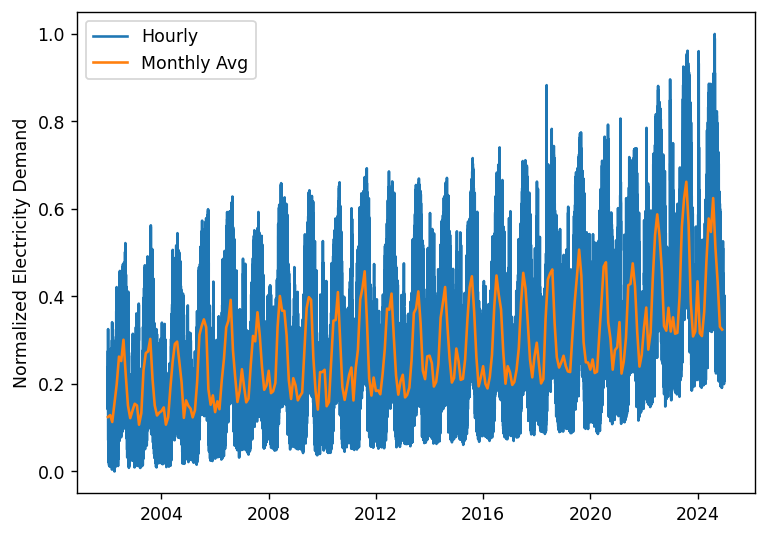

In [3]:
# Plot a monthly rolling average versus the true hourly value
monthly_norm = full_df['load'].resample('MS').mean().bfill()
plt.plot(full_df['load'], label='Hourly')
plt.plot(monthly_norm, label='Monthly Avg')
plt.ylabel('Normalized Electricity Demand')
plt.legend();

In [4]:
# Trained on 2002 to 2014, validated on 2015-2016, tested on 2017-2024
train, validate, test = FeatureEngineering.train_test_split(monthly_norm, 2014, 2015, 2016, 2017)

## TPOT

In [26]:
monthly_norm.index.shape

(276,)

In [27]:
B = np.reshape(monthly_norm.index, (-1, 2))

In [29]:
from tpot import TPOTRegressor

tpot_reg = TPOTRegressor()

tpot_reg.fit(B, np.array(monthly_norm.values).ravel())
print(tpot_ref.score(monthly_norm.index))

Generation: : 0it [00:00, ?it/s]/home/lambpc/.conda/envs/AustinTXForecast/lib/python3.13/site-packages/stopit/__init__.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Exception: No individuals could be evaluated in the initial population. This may indicate a bug in the configuration, included models, or objective functions. Set verbose>=4 to see the errors that caused individuals to fail.

In [9]:
import joblib 

# Predict forecasted values 
model_sarima, sarima_forec, sarima_pred, sarima_ci = sarima_modeling.sarima(train, validate, 1, 1, 1, 0, 1, 1)
print('MAE:', ForecastingHelpers.compute_mae(validate, sarima_pred))
# Save the model
filename = 'ElectricityDemandAustinTX/LoadForecastingAttacks/SaveFiles/sarima.joblib'
joblib.dump(model_sarima, filename)

MAE: 0.023728585451924144


['ElectricityDemandAustinTX/LoadForecastingAttacks/SaveFiles/sarima.joblib']

Data up to 2016 (training + validation)

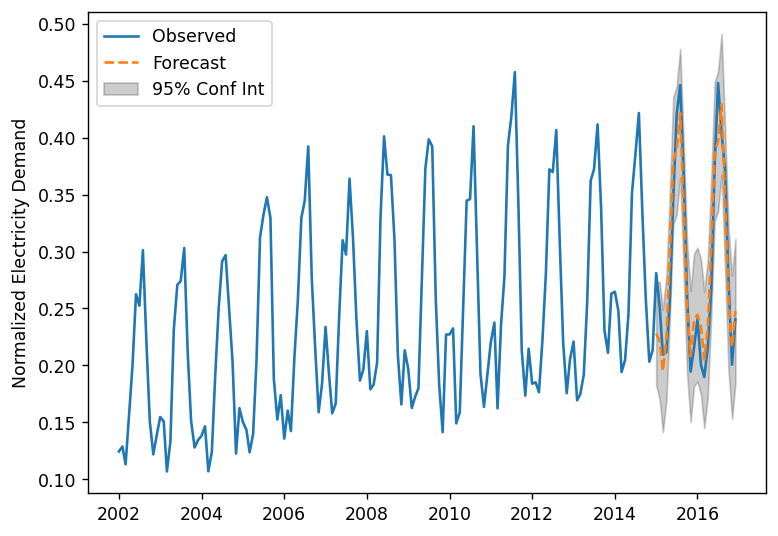

In [10]:
# plotting training and validation
plt.plot(monthly_norm[:'2016'], label='Observed')
plt.plot(sarima_pred, label='Forecast', ls='--')
plt.fill_between(sarima_ci.index, sarima_ci.iloc[:,0], sarima_ci.iloc[:,1],
                 color='k', alpha=0.2, label='95% Conf Int')
plt.ylabel('Normalized Electricity Demand')
plt.legend();

Data 2017 and beyond

In [11]:
# Predict forecasted values for testing
drift_sarima, drift_forec, drift_pred, drift_ci = sarima_modeling.sarima(pd.concat([train, validate]), test, 1, 1, 1, 0, 1, 1)
print('MAE:', ForecastingHelpers.compute_mae(test, drift_pred))

MAE: 0.04606286473177642


In [12]:
# Convert prediction and confidence interval for validation and testing datasets to Pandas Dataframes 
# to be used to find the deviation of the confidence interval width
drift_ci.set_index(test.index, inplace=True)
preds = pd.concat([sarima_pred, drift_pred])
ci = pd.concat([sarima_ci, drift_ci])

Find where the prediction and the true power start deviating to come up with a "lifespan" of the model prior to retraining. The blackline represents where the division happens where the model falls out of the original 95% confidence interval width.

In [13]:
# Get the confidence interval width (c_x) right after training and validation and compare to the confidence interval width iterated to the point where
# the width of the interval exceeds the width of c_x, labeling it 'div' as the point at which a division happens.
for i, index_label in enumerate(drift_ci.index):
        lb = drift_ci.iloc[i,0]
        ub = drift_ci.iloc[i,1]
        c_x = sarima_ci.iloc[-1,1]-sarima_ci.iloc[-1,0]
        if ub-lb > c_x:
            div = index_label
            load_div = preds[i]
            break
        else:
            div = ci.index[-1]

In [14]:
div

Timestamp('2019-04-01 00:00:00')

In [15]:
# Calculate the KL Divergence using SciPy's KL divergence modeling technique, where 
diverge = ForecastingHelpers.calculateKLDivergence(monthly_norm['2017':],preds)

In [16]:
# PSI, which is a deviation of KL divergence can be used to determe drift, it is the symmetric version of KL divergence.
psi = ForecastingHelpers.calculatePSI(monthly_norm['2017':],preds)

Low drift <= 0.1, Moderate drift <= 0.25, Significant drift > 0.25 for PSI. If converted to KL Divergence, KL divergence acts as a slightly more conservative estimate.

https://link.springer.com/article/10.1007/s42488-024-00119-y

In [17]:
med_drift, high_drift = ForecastingHelpers.testDivergence(diverge, test)
med_drift

Timestamp('2021-02-01 00:00:00')

In [18]:
med_PSI, high_PSI = ForecastingHelpers.testPSI(psi, test)
med_PSI

Timestamp('2021-02-01 00:00:00')

In [19]:
print("Exceeds confidence interval: "  + str(ForecastingHelpers.MTTF(preds, div)) + " Exceeds 0.1 divergence: " + str(ForecastingHelpers.MTTF(preds, med_drift)))

Exceeds confidence interval: 1551 days 00:00:00 Exceeds 0.1 divergence: 2223 days 00:00:00


KL divergence increases prior to the divergence point which can assist with determining when drift occurs. 

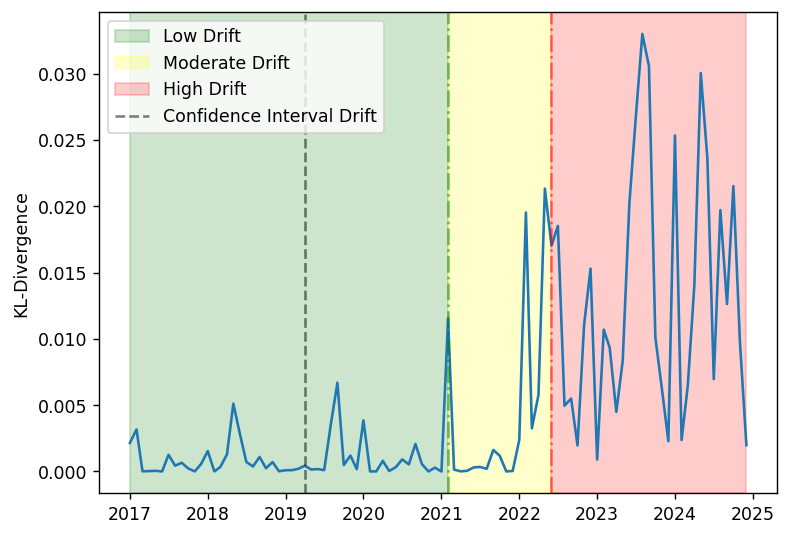

In [20]:
import matplotlib.pyplot as plt
plt.plot(diverge)
plt.ylabel('KL-Divergence')
plt.axvline(x=med_drift, color="green", alpha=0.5, linestyle="-.")
plt.axvline(x=high_drift, color="red", alpha=0.5, linestyle="-.")
plt.axvspan(test.index[0],med_drift, color='green', alpha=0.2, label="Low Drift")
plt.axvspan(med_drift,high_drift, color='yellow', alpha=0.2, label="Moderate Drift")
plt.axvspan(high_drift,test.index[-1], color='red', alpha=0.2, label="High Drift")
plt.axvline(x=div, color="black", alpha=0.5, linestyle="--", label="Confidence Interval Drift")
plt.legend()

Most models in production now use accuracy for determining when the model should be retrained. We prove that using the "90%" rule for grid operation drift management is a less efficient way at determining drift, where KL divergence and confidence intervals can be used prior to the model impacting accuracy.

In [21]:
mae_threshold = ForecastingHelpers.compute_mae(validate, sarima_pred)*0.9
mae_drift = (np.abs(drift_pred - test)).cumsum()/len(test)
rmse_drift = np.sqrt(((drift_pred - test).cumsum()**2)/len(test))
mae_point = mae_drift.index[mae_drift.searchsorted(mae_threshold)]
rmse_threshold = np.sqrt(np.mean((sarima_pred - validate) ** 2))*0.9
rmse_point = rmse_drift.index[rmse_drift.searchsorted(rmse_threshold)]

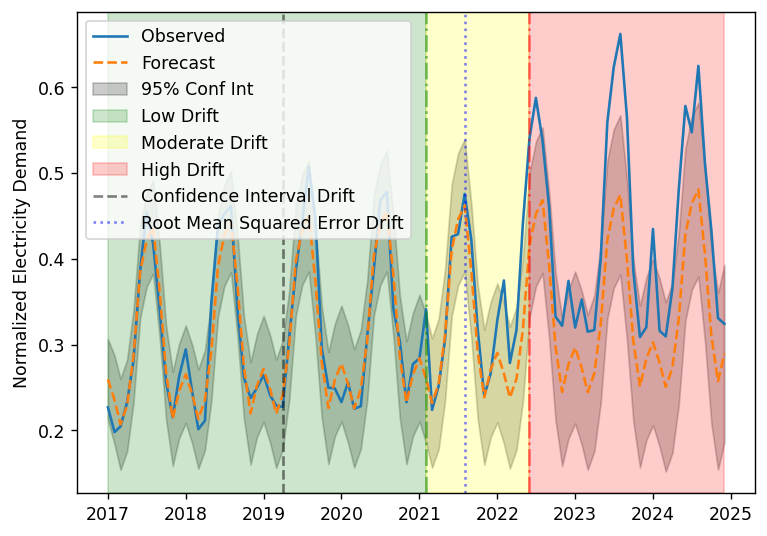

In [22]:
# plotting
plt.plot(test[:'2025'], label='Observed')
plt.plot(drift_pred, label='Forecast', ls='--')
plt.fill_between(drift_ci.index, drift_ci.iloc[:,0], drift_ci.iloc[:,1],
                 color='k', alpha=0.2, label='95% Conf Int')
plt.axvline(x=med_drift, color="green", alpha=0.5, linestyle="-.")
plt.axvspan(drift_pred.index[0],med_drift, color='green', alpha=0.2, label="Low Drift")
plt.axvspan(med_drift,high_drift, color='yellow', alpha=0.2, label="Moderate Drift")
plt.axvspan(high_drift,drift_pred.index[-1], color='red', alpha=0.2, label="High Drift")
plt.axvline(x=high_drift, color="red", alpha=0.5, linestyle="-.")
plt.axvline(x=div, color="black", alpha=0.5, linestyle="--", label="Confidence Interval Drift")
plt.axvline(x=rmse_point, color="blue", alpha=0.5, linestyle=":", label="Root Mean Squared Error Drift")
plt.ylabel('Normalized Electricity Demand')
plt.legend();

In [23]:
rmse_threshold = np.sqrt(np.mean((validate - sarima_pred) ** 2))*0.9

In [24]:
rmse_point = rmse_drift.index[rmse_drift.searchsorted(rmse_threshold)]

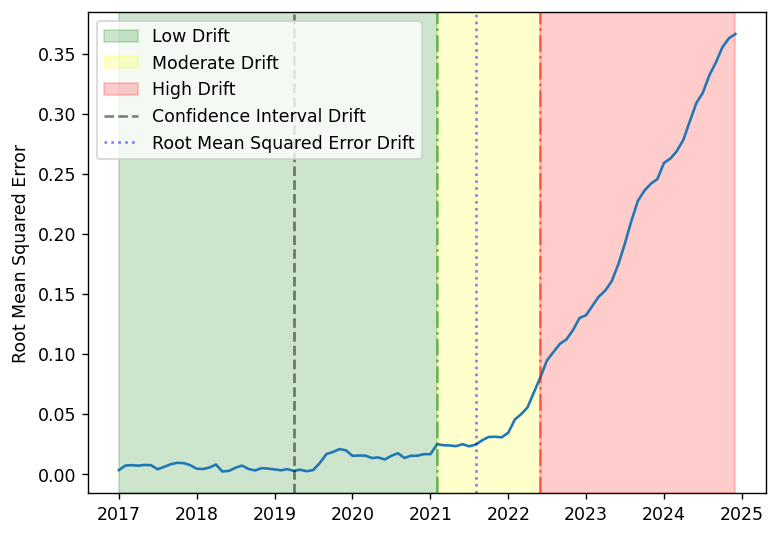

In [25]:
plt.plot(rmse_drift)
plt.ylabel('Root Mean Squared Error')
plt.axvline(x=med_drift, color="green", alpha=0.5, linestyle="-.")
plt.axvspan(drift_pred.index[0],med_drift, color='green', alpha=0.2, label="Low Drift")
plt.axvspan(med_drift,high_drift, color='yellow', alpha=0.2, label="Moderate Drift")
plt.axvspan(high_drift,preds.index[-1], color='red', alpha=0.2, label="High Drift")
plt.axvline(x=high_drift, color="red", alpha=0.5, linestyle="-.")
plt.axvline(x=div, color="black", alpha=0.5, linestyle="--", label="Confidence Interval Drift")
plt.axvline(x=rmse_point, color="blue", alpha=0.5, linestyle=":", label="Root Mean Squared Error Drift")
plt.legend();

In [26]:
print("Exceeds confidence interval: "  + str(ForecastingHelpers.MTTF(preds, div)) + " Exceeds 0.1 divergence: " + str(ForecastingHelpers.MTTF(preds, med_drift)) + " Exceeds 90% Accuracy: " + str(ForecastingHelpers.MTTF(preds, rmse_point)))

Exceeds confidence interval: 1551 days 00:00:00 Exceeds 0.1 divergence: 2223 days 00:00:00 Exceeds 90% Accuracy: 2404 days 00:00:00


In [27]:
print(div)
print(med_drift)
print(rmse_point)

2019-04-01 00:00:00
2021-02-01 00:00:00
2021-08-01 00:00:00


In [28]:
print(test.index[0])

2017-01-01 00:00:00
